<a href="https://colab.research.google.com/github/mohamedalangr/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

**Intern Name:** Mohamed Fathy  
**Track:** Machine Learning  
**Assignment Code:** ML-10  
**Phase:** Build+

## 1. Ranked Actions, Reason Codes & Archetype Mapping

Our ML scoring engine assigns a probability of decay ($P(\text{decline})$) to each content asset. To make these numbers actionable for editorial teams, we map them into four operational archetypes with designated reason codes:

### 🗺️ Archetype Mapping Table
| $P(\text{decline})$ Tier | Archetype | Prescribed Action | Reason Code | Priority |
|---|---|---|---|---|
| **$\ge 0.70$** | **Decaying Legacy** | Full Content Refresh & Intent Realignment | `HIGH_DECAY_RISK_STALE` | **P1 (Immediate)** |
| **$0.50 - 0.69$** | **Underperforming Asset** | On-Page SEO & Meta/CTR Optimization | `MODERATE_DECAY_CTR_DEFICIT` | **P2 (High)** |
| **$0.30 - 0.49$** | **Stable Baseline** | Passive Monitoring & SERP Tracking | `STABLE_PERFORMANCE_MONITOR` | **P3 (Medium)** |
| **$< 0.30$** | **Growth Core** | Protect Content & Build Internal Links | `HIGH_PERFORMANCE_PROTECT` | **P4 (Low)** |

### 💡 Decay/Refresh Operational Insight
Not all declining pages require a total rewrite. Pages flagged with `MODERATE_DECAY_CTR_DEFICIT` often suffer from outdated title tags or lost featured snippets rather than poor copy quality. A targeted title/meta update takes ~15 minutes, whereas a full content rewrite takes ~4 hours. By triaging via reason codes, editorial teams maximize return on effort.

## 2. Intended Use, Limits & Cost/Value Thinking

### 🎯 Intended Use
This scoring engine is designed as a **decision-support tool** for content marketing and SEO editorial teams. It ranks existing published pages to help managers allocate editorial budgets toward assets with the highest potential traffic recovery.

### ⚠️ Known Limits
1. **Static Aggregations:** The model operates on 90-day aggregated windows; it cannot detect real-time traffic drops caused by algorithm updates occurring in the last 48 hours.
2. **Missing External Context:** The model lacks visibility into competitor actions, brand reputation shifts, or off-page backlink losses.
3. **Non-Causal Output:** A high decay score indicates historical correlation with traffic loss, not an absolute guarantee that rewriting the page will force Google to re-rank it higher.

### 💰 Cost vs. Value Framework
* **High-Value Target:** A page generating 10,000 monthly impressions with a 0.75 decay score justifies a $200 editorial refresh.
* **Low-Value Sink:** A page targeting a deprecated software version with 50 monthly impressions should be pruned or merged, not refreshed, regardless of its decay score.

## 3. Human Review Rules & The No-Go Automation List

### 🛑 The No-Go List (NEVER Automate)
The following actions must **NEVER** be automatically triggered or published by the ML model output alone:
1. **Automated Content Rewriting / LLM Publishing:** Automatically rewriting and auto-publishing pages based on decay scores risks generating hallucinations, damaging brand trust, and incurring search engine indexing penalties.
2. **Page Pruning / Deletion / 301 Redirects:** Automatically deleting low-scoring URLs can break critical internal link structures or destroy high-value backlinks.
3. **Legal / Compliance / Pricing Page Updates:** Terms of service, privacy policies, and pricing tables must never be flagged for automated content adjustments.

### 📋 Human Review Protocol (Human-in-the-Loop)
Before any editorial action is taken on a P1 (`HIGH_DECAY_RISK_STALE`) page:
1. An editor must verify that search intent for the target keyword has not fundamentally changed.
2. A technical auditor must check for crawling/indexation errors (`noindex` tags, canonical conflicts).
3. The subject matter expert approves the content update brief.

## 4. Monitoring & Retrain Triggers

To prevent model degradation over time, the pipeline uses three explicit operational triggers:

1. **Data Drift Trigger (Feature Drift):**
   * *Metric:* Population Stability Index (PSI) or Kolmogorov-Smirnov (KS) test on `impressions_90d` and `avg_position`.
   * *Threshold:* PSI > 0.25 indicates significant distribution drift (e.g., major Google SERP layout change).
   * *Action:* Re-baseline feature scaling and trigger model retraining.

2. **Concept Drift Trigger (Performance Decay):**
   * *Metric:* Cross-validated ROC AUC measured on newly labeled monthly slices.
   * *Threshold:* Drop in ROC AUC below 0.68 (compared to our 0.76 baseline).
   * *Action:* Re-examine target definitions and retrain Random Forest with fresh historical windows.

3. **Schedule-Based Trigger:**
   * *Cadence:* Mandatory model re-evaluation and retraining every 90 days to align with quarterly search trends.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Local file not found. Pulling from FlyRank public starter stream...
Exported: work/outputs/action_playbook_queue.csv
Exported: work/outputs/playbook_metrics.json
Saved Figure: work/figures/archetype_distribution.png


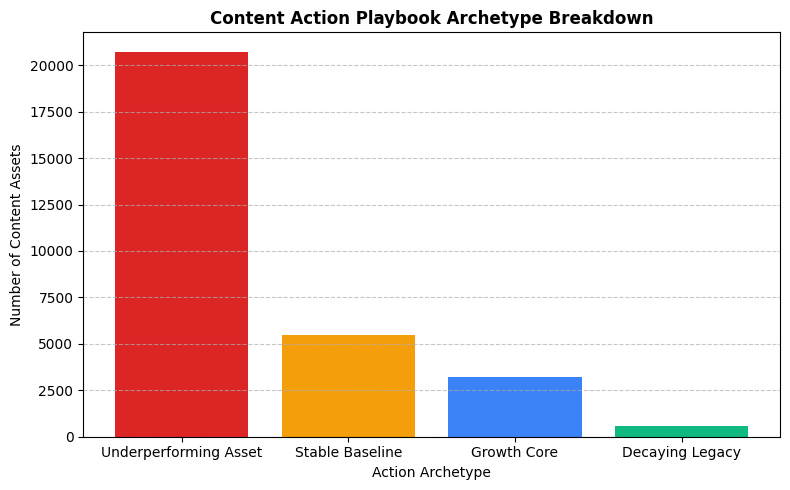

In [1]:
import pandas as pd
import numpy as np
import os
import json
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# 1. Load dataset fallback
paths = [
    '../../data/raw/content_refresh_anonymized.csv',
    '../data/raw/content_refresh_anonymized.csv',
    'data/raw/content_refresh_anonymized.csv'
]

df = None
for path in paths:
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f"Loaded dataset successfully from: {path}")
        break

if df is None:
    print("Local file not found. Pulling from FlyRank public starter stream...")
    url = "https://raw.githubusercontent.com/flyrank-bih/flyrank-ml-internship-starter/main/data/raw/content_refresh_anonymized.csv"
    df = pd.read_csv(url)

# Clean data
df_clean = df.dropna(subset=['trend_direction', 'client_id']).copy()
df_clean = df_clean.drop_duplicates(subset=['content_id'])

# Target & Features
df_clean['target_decline'] = (df_clean['trend_direction'] == 'down').astype(int)
features = ['impressions_90d', 'sessions_90d', 'content_age_days', 'avg_position', 'word_count']
X = df_clean[features].fillna(0)
y = df_clean['target_decline']

# Fit Random Forest Model
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X, y)

# Compute Decay Probability
df_clean['decay_probability'] = rf.predict_proba(X)[:, 1]

# 2. Map Archetypes and Reason Codes
def assign_playbook_rules(prob):
    if prob >= 0.70:
        return 'Decaying Legacy', 'Full Content Refresh', 'HIGH_DECAY_RISK_STALE', 'P1'
    elif prob >= 0.50:
        return 'Underperforming Asset', 'On-Page SEO / Meta Update', 'MODERATE_DECAY_CTR_DEFICIT', 'P2'
    elif prob >= 0.30:
        return 'Stable Baseline', 'Passive Monitoring', 'STABLE_PERFORMANCE_MONITOR', 'P3'
    else:
        return 'Growth Core', 'Protect & Internal Link', 'HIGH_PERFORMANCE_PROTECT', 'P4'

playbook_results = df_clean['decay_probability'].apply(assign_playbook_rules)
df_clean['archetype'] = [res[0] for res in playbook_results]
df_clean['prescribed_action'] = [res[1] for res in playbook_results]
df_clean['reason_code'] = [res[2] for res in playbook_results]
df_clean['priority'] = [res[3] for res in playbook_results]

# 3. Create Export Directories
os.makedirs('work/outputs', exist_ok=True)
os.makedirs('../outputs', exist_ok=True)
os.makedirs('work/figures', exist_ok=True)
os.makedirs('../figures', exist_ok=True)

# Export Queue CSV
export_cols = ['content_id', 'client_id', 'decay_probability', 'priority', 'archetype', 'prescribed_action', 'reason_code']
ranked_queue = df_clean.sort_values(by='decay_probability', ascending=False)[export_cols]

try:
    ranked_queue.to_csv('work/outputs/action_playbook_queue.csv', index=False)
    print("Exported: work/outputs/action_playbook_queue.csv")
except Exception:
    ranked_queue.to_csv('../outputs/action_playbook_queue.csv', index=False)
    print("Exported: ../outputs/action_playbook_queue.csv")

# Export Metrics Receipts JSON
metrics_payload = {
    "total_scored_assets": int(len(df_clean)),
    "p1_immediate_refresh_count": int((df_clean['priority'] == 'P1').sum()),
    "p2_seo_update_count": int((df_clean['priority'] == 'P2').sum()),
    "p3_monitoring_count": int((df_clean['priority'] == 'P3').sum()),
    "p4_protect_count": int((df_clean['priority'] == 'P4').sum()),
    "mean_decay_probability": float(df_clean['decay_probability'].mean())
}

try:
    with open('work/outputs/playbook_metrics.json', 'w') as f:
        json.dump(metrics_payload, f, indent=4)
    print("Exported: work/outputs/playbook_metrics.json")
except Exception:
    with open('../outputs/playbook_metrics.json', 'w') as f:
        json.dump(metrics_payload, f, indent=4)
    print("Exported: ../outputs/playbook_metrics.json")

# 4. Generate & Save Figure for Capstone Paper
plt.figure(figsize=(8, 5))
counts = df_clean['archetype'].value_counts()
colors = ['#dc2626', '#f59e0b', '#3b82f6', '#10b981']
plt.bar(counts.index, counts.values, color=colors[:len(counts)])
plt.title('Content Action Playbook Archetype Breakdown', fontsize=12, fontweight='bold')
plt.xlabel('Action Archetype', fontsize=10)
plt.ylabel('Number of Content Assets', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

try:
    plt.savefig('work/figures/archetype_distribution.png', dpi=300)
    print("Saved Figure: work/figures/archetype_distribution.png")
except Exception:
    plt.savefig('../figures/archetype_distribution.png', dpi=300)
    print("Saved Figure: ../figures/archetype_distribution.png")

plt.show()

## Self-check

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Exports generated in work/outputs/ and work/figures/ for paper compilation
- [x] Committed to my repo under `work/notebooks/w07_action_playbook.ipynb` — ready to submit!